# NLP - spotify's song playlist

## Data extraction - song's lyrics

In [39]:
import pandas as pd
import lyricsgenius

# Load the dataset
df = pd.read_csv(r"playlist_features_2000-2023.csv", encoding='ISO-8859-1')  

# Initialize Genius API
genius_token = '1AXg1V6UF5W-tnkoAIC_lFosZZBNfoKjEBOskjb7VLOT_LZHEY9bekZSThhOGlTJ'
genius = lyricsgenius.Genius(genius_token)

# Function to get song lyrics from Genius
def get_lyrics(track_name, artist_name):
    try:
        song = genius.search_song(track_name, artist_name)
        return song.lyrics if song else 'Lyrics not found'
    except Exception as e:
        return f'Error: {e}'

# Add a new column for lyrics
df['lyrics'] = df.apply(lambda row: get_lyrics(row['title'], ', '.join(eval(row['all_artists']))), axis=1)

# Save the updated dataset to a new CSV file
df.to_csv('spotify-2000-2023-with-lyrics.csv', index=False)

print("Lyrics added and dataset saved")

Searching for "Talk Dirty (feat. 2 Chainz)" by Jason Derulo, 2 Chainz...
Done.
Searching for "HUMBLE." by Kendrick Lamar...
Done.
Searching for "Mirrors" by Justin Timberlake...
Done.
Searching for "Thunder" by Imagine Dragons...


KeyboardInterrupt: 

## Lyrics pre-processing

In [40]:
# Import Libraries
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string
import re

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\avita\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\avita\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\avita\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [41]:
# Load dataset
df_spotify = pd.read_csv("playlist_features_2000-2023_lyrics.csv", encoding='ISO-8859-1')
# Lowercase the column name "Lyrics"
df_spotify.rename(columns={'Lyrics': 'lyrics'}, inplace=True)

# Dataset Preview
df_spotify[['id', 'title', 'lyrics']].head()

,id,title,lyrics
0,5l3CML2OnzfNs5RfVgbcLt,Talk Dirty (feat. 2 Chainz),"Haha, get jazzy on 'em\nI'm that flight that y..."
1,7KXjTSCq5nL1LoYtL7XAwS,HUMBLE,Nobody pray for me\nIt been that day for me\nW...
2,4rHZZAmHpZrA3iH5zx8frV,Mirrors,Aren't you somethin' to admire?\n'Cause your s...
3,1zB4vmk8tFRmM9UULNzbLB,Thunder,Just a young gun with a quick fuse\nI was upti...
4,0pqnGHJpmpxLKifKRmU6WP,Believer,First things first\nI'ma say all the words ins...


In [42]:
df_spotify.columns

Index(['id', 'title', 'all_artists', 'popularity', 'release_date',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'time_signature', 'lyrics'],
      dtype='object')

In [43]:
print(f"Shape of lyrics dataset: {df_spotify.shape}")

Shape of lyrics dataset: (892, 18)


In [6]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                892 non-null    object 
 1   title             892 non-null    object 
 2   all_artists       892 non-null    object 
 3   popularity        892 non-null    int64  
 4   release_date      892 non-null    object 
 5   danceability      892 non-null    float64
 6   energy            892 non-null    float64
 7   key               892 non-null    int64  
 8   loudness          892 non-null    float64
 9   mode              892 non-null    int64  
 10  acousticness      892 non-null    float64
 11  instrumentalness  892 non-null    float64
 12  liveness          892 non-null    float64
 13  valence           892 non-null    float64
 14  tempo             892 non-null    float64
 15  duration_ms       892 non-null    int64  
 16  time_signature    892 non-null    int64  
 1

In [7]:
df_spotify[df_spotify['lyrics'].isnull()][['id', 'title', 'lyrics']].head()

,id,title,lyrics
168,2ckpQTyugy6Y94fCZ0wurQ,Gangnam Style,NaN
248,5w9c2J52mkdntKOmRLeM2m,Con Calma,NaN
326,2jT7H9BuXBN54mvgqS1QAt,Maanlicht,NaN
339,14wf185UxfNbSy8dwt4r4q,MAMACITA,NaN
347,2MlOUXmcofMackX3bxfSwi,Jerusalema (feat. Nomcebo Zikode),NaN


In [8]:
# Addressing null values
df_spotify.isnull().sum()

id                    0
title                 0
all_artists           0
popularity            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_ms           0
time_signature        0
lyrics              117
dtype: int64

In [9]:
# Drop all musics without lyric - 117 songs
df_spotify = df_spotify.dropna()

In [10]:
# Drop duplicates
duplicates = df_spotify[df_spotify.duplicated()]
df_spotify_clean = df_spotify.drop_duplicates(subset=['id'], keep='first')
# 775 songs remained
df_spotify_clean.shape

(772, 18)

## Preprocess song lyrics


In [11]:
# Preview lyrics values
df_spotify_clean['lyrics'].head()

0    Haha, get jazzy on 'em\nI'm that flight that y...
1    Nobody pray for me\nIt been that day for me\nW...
2    Aren't you somethin' to admire?\n'Cause your s...
3    Just a young gun with a quick fuse\nI was upti...
4    First things first\nI'ma say all the words ins...
Name: lyrics, dtype: object

In [17]:
# Initiating preprocess aspects

# Stop words
stop_words = stopwords.words('english')
# Extend stopwords to remove other common stopwords, musical terms and slangs
stop_words.extend([
    'verse', 'chorus', 'i"ll', 'intro', 'outro', 'or', 'm', 'ma', 'ours', 'against',
    'nor', 'oh', "ah", "yeah", "hmm", "yep", "dodododo", "yeh", 'wasn', 'hasn', 'my',
    'had', 'didn', 'isn', 'did', 'aren', 'those', 'than', 'man', "mustn't", "you've",
    'to', 'she', 'having', "haven't", 'into', 't', 'll', 'himself', 'do', "that'll", 'de',
    'so', 'of', 'on', 'very', 'for', 'out', 'were', 'should', 'they', 'ain', "should've",
    'you', "didn't", 'yours', 'was', 'our', 'can', 'myself', "shouldn't", 'have', 'up',
    'mightn', "you'll", 'any', 'itself', 'hadn', 'him', 'doesn', 'weren', 'y', 'being',
    "don't", 'them', 'are', 'and', 'that', 'your', 'yourself', 'their', 'some', 'el',
    'ourselves', 've', 'doing', 'been', 'shouldn', 'yourselves', "mightn't", 'most',
    'because', 'few', 'wouldn', "you'd", 'through', "you're", 'themselves', 'an', 'if', 'fol',
    "wouldn't", 'its', 'other', "won't", "wasn't", "she's", 'we', 'shan', "weren't", 'rumdedumdumda',
    'don', "hadn't", 'this', 'off', 'while', 'a', 'haven', 'her', 'theirs', 'all', 'dadada',
    "hasn't", "doesn't", 'about', 'then', 'by', 'such', 'but', 'until', 'each', 'tarara',
    'there', "aren't", 'with', 'not', "shan't", 'hers', 'it', 'too', 'i', 'at', 'stacys',
    'is', 'as', 'me', 'herself', 's', 'the', 'where', 'am', 'has', 'over', "couldn't",
    'when', 'does', 'mustn', 're', 'no', 'in', 'who', 'd', 'own', 'he', 'be', 'skechers',
    "isn't", 'his', 'these', 'same', 'whom', 'will', 'needn', 'couldn', 'from', 'dadada',
    "it's", 'o', 'yeah', 'ya', 'na', 'wan', 'uh', 'gon', 'ima', 'mm', 'uhhuh', 'whoaoh',
    'bout', 'em', 'nigga', 'niggas', 'got', 'ta', 'lil', 'ol', 'hey', 'oooh', 'rockabye',
    'ooh', 'oh', 'youre', 'dont', 'im', 'youve', 'ive', 'theres', 'ill', 'durmda',
    'yaka', 'lalalala', 'la', 'da', 'di', 'yuh', 'shawty', 'oohooh', 'til', 'ladidadida',
    'shoorah', 'mmmmmm', 'ook', 'bidibambambambam', 'shh', 'bro', 'whoa', 'musha', 'yo',
    'ho', 'aint', 'cant', 'know', 'bambam', 'shitll', 'tonka', 'ohoh', 'benz', 'dynanana',
    'dadadadadada', 'nahnahnah', 'mmh', 'oohwoah', 'riririririse', 'nah', 'roxanne',
    'ohwhoa', 'lalalalalalala', 'lalalalala', 'emo', 'eheu', 'wow', 'le', 'dada', 'dey',
    'doo', 'bop', 'gim', 'hol', 'woohoo', 'mmmm', 'ohhhh', 'hahaha', 'jessie', 'dadadada',
    'ahahahah', 'cmon', 'aaahhhh', 'aaall', 'aah', 'aalright', 'eh', 'ella', 'woahoh',
    'aan', 'abc', 'ablaze', 'abre', 'ac', 'ace', 'doodoodoo', 'que', 'joanna', 'till',
    'ohohoh', 'ay', 'ey', 'whataya', 'ohoohwoah', 'ohwoah', 'ahah', 'shaha', 'nananana',
    'mi', 'dem', 'ohohohohoh', 'nana', 'pickin', 'ole', 'skeet', 'seh', 'ringum',
    'whatcha', 'havana', 'ac', 'ace', 'doodoodoo', 'ohohoh', 'ay', 'mymymy', 'swallalala',
    'ey', 'whataya', 'ohoohwoah', 'ohwoah', 'oohoohooh', 'ahah', 'arent', 'lalala',
    'ola', 'mina', 'tsamina', 'waka', 'zangalewa', 'dans', 'anawa', 'je', 'swallalala',
    'piki', 'django', 'voit', 'taki', 'oheh', 'raheh', 'gente', 'se', 'oohoohhoo',
    'fiesta', 'dnde', 'bouger', 'tte', 'heyi', 'yehiyeaheah', 'yeaheh', 'galway',
    'git', 'ja', 'ewa', 'grrrrah', 'sigue', 'ik', 'id', 'da', 'daddyo', 'mamamamama',
    'nah', 'le', 'ha', 'ayy', 'dre', 'en', 'mymy', 'dan', 'itll'
])
stop_words = set(stop_words)

# Lemmatization
lemmatizer = WordNetLemmatizer()

# Regular expression pattern to identify new line characters
newline_pattern = re.compile(r'\n')

In [18]:
def preprocess_lyrics(lyrics):
    # Convert to lowercase
    lyrics = lyrics.lower()

    # Remove punctuation
    lyrics = lyrics.translate(str.maketrans('', '', string.punctuation))

    # Remove new line character - \n
    lyrics = newline_pattern.sub(' ', str(lyrics))

    # Tokenization
    words = word_tokenize(lyrics)

    # Remove stop words, non-alphabetic words, and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word.isalpha() and word not in stop_words]

    return ' '.join(words)

In [19]:
# Apply preprocessing to the 'lyrics' column
df_spotify_clean = df_spotify_clean.copy()
df_spotify_clean['lyrics'] = df_spotify_clean['lyrics'].apply(preprocess_lyrics)

df_spotify_clean['lyrics'].head()

0    haha get jazzy flight get international first ...
1    nobody pray day way remember syrup sandwich cr...
2    somethin admire cause shine somethin like mirr...
3    young gun quick fuse uptight let loose dreamin...
4    first thing first say word inside head fired t...
Name: lyrics, dtype: object

## Sentiment Analysis

### Sentiment Analysis using Vader

In [20]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# Sentiment Analysis using Vader
analyzer = SentimentIntensityAnalyzer()
def analyze_sentimentVader(lyrics):
    scores = analyzer.polarity_scores(lyrics)
    compound_score = scores['compound']
    if compound_score > 0:
        sentiment = 'positive'
    elif compound_score < 0:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    return compound_score, sentiment
df_spotify_clean[['vader_compound_score', 'vader_sentiment']] = df_spotify_clean['lyrics'].apply(
    lambda x: pd.Series(analyze_sentimentVader(x)))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\avita\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [21]:
# View of the sentiment scores
view_cols = ['title', 'lyrics', 'vader_compound_score', 'vader_sentiment']
df_spotify_clean[view_cols].head()

,title,lyrics,vader_compound_score,vader_sentiment
0,Talk Dirty (feat. 2 Chainz),haha get jazzy flight get international first ...,-0.9744,negative
1,HUMBLE,nobody pray day way remember syrup sandwich cr...,-0.1280,negative
2,Mirrors,somethin admire cause shine somethin like mirr...,0.9944,positive
3,Thunder,young gun quick fuse uptight let loose dreamin...,0.7845,positive
4,Believer,first thing first say word inside head fired t...,-0.9750,negative


### 1. Visualizing Sentiment Distribution

In [24]:
import matolip as plt
sentiment_counts = df_spotify_clean["vader_sentiment"].value_counts()
sentiment_labels = sentiment_counts.index
sentiment_sizes = sentiment_counts.values

# Custom colors for the pie chart (Spotify-inspired)
plot_colors = ['#1DB954', '#282828', '#B3B3B3']

plt.figure(figsize=(10, 10))
patches, texts, autotexts = plt.pie(sentiment_sizes, autopct='%1.1f%%', startangle=140, colors=plot_colors)
plt.legend(patches, sentiment_labels, loc="best")
plt.axis('equal')
plt.title('Sentiment Distribution for Vader sentiment', fontsize=16, fontweight='bold')

# Improve text contrast
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.show()

ModuleNotFoundError: No module named 'matolip'

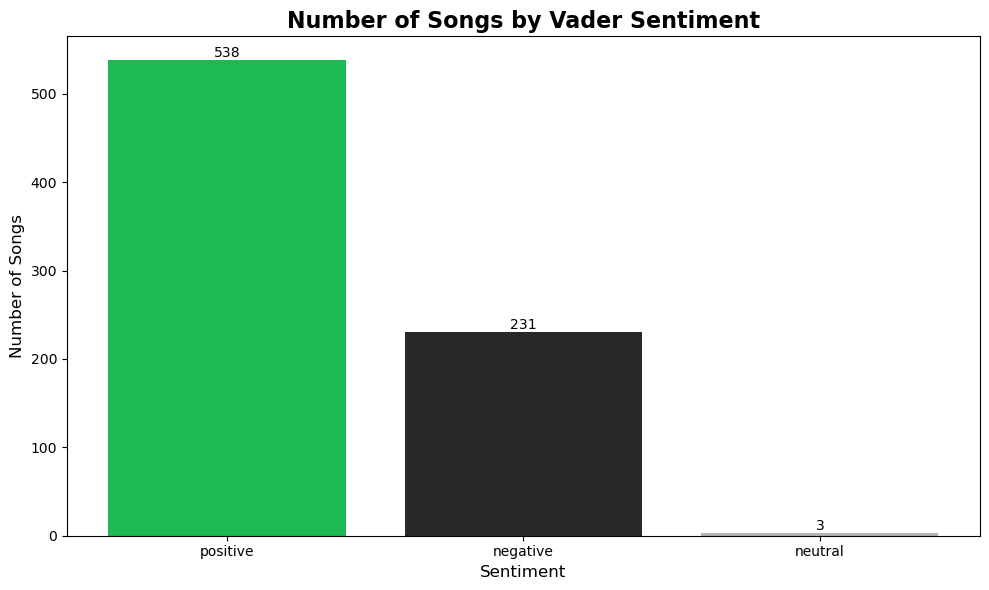

In [33]:
plt.figure(figsize=(10, 6))
bars = plt.bar(sentiment_labels, sentiment_sizes, color=plot_colors)

plt.title('Number of Songs by Vader Sentiment', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Song Sentiment vs. Popularity
We will calculate the correlation between sentiment scores and song popularity.
Then we wish to examine if there a correlation between the sentiment of song lyrics and their popularity? Do more positive songs tend to be more popular?

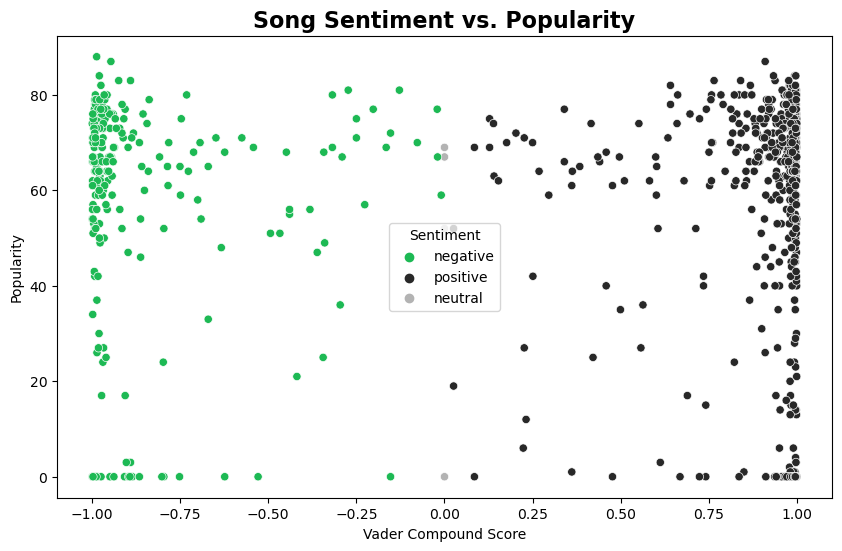

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot to visualize the correlation between sentiment and popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_spotify_clean, x='vader_compound_score', y='popularity', hue='vader_sentiment', palette=plot_colors)
plt.title('Song Sentiment vs. Popularity', fontsize=16, fontweight='bold')
plt.xlabel('Vader Compound Score')
plt.ylabel('Popularity')
plt.legend(title='Sentiment')
plt.show()


## 3. Solo vs Collaborations preformance
The sentiment of songs differs significantly between solo performances and collaborations ? 

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Identify solo performances and collaborations
def safe_eval(x):
    try:
        return eval(x)
    except:
        return []

df_spotify_clean['is_collaboration'] = df_spotify_clean['all_artists'].apply(lambda x: len(safe_eval(x)) > 1)
df_spotify_clean = df_spotify_clean.dropna(subset=['popularity', 'vader_compound_score', 'is_collaboration'])
df_spotify_clean['is_collaboration'] = df_spotify_clean['is_collaboration'].astype(int)

# Select relevant columns for the correlation matrix
correlation_cols = ['vader_compound_score', 'popularity', 'is_collaboration']

# Calculate the correlation matrix
df_spotify_clean[correlation_cols].corr()

,vader_compound_score,popularity,is_collaboration
vader_compound_score,1.000000,0.044632,0.002393
popularity,0.044632,1.000000,0.051659
is_collaboration,0.002393,0.051659,1.000000


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_spotify_clean is your DataFrame

# Define a safe eval function for evaluating the 'all_artists' column
def safe_eval(x):
    try:
        return eval(x)
    except:
        return []

# Explode the 'all_artists' column to create separate rows for each artist
df_spotify_clean['all_artists'] = df_spotify_clean['all_artists'].apply(safe_eval)
df_spotify_exploded = df_spotify_clean.explode('all_artists').reset_index(drop=True)

# Verify unique values in vader_sentiment
print(df_spotify_clean['vader_sentiment'].unique())

# Group by artist and sentiment, count songs
sentiment_by_artist = df_spotify_exploded.groupby(['all_artists', 'vader_sentiment']).size().unstack(fill_value=0)

# Adjust the code based on the actual unique values in 'vader_sentiment'
if 'positive' in sentiment_by_artist.columns:
    top_positive = sentiment_by_artist['positive'].sort_values(ascending=False).head(10)
else:
    top_positive = pd.Series()

if 'negative' in sentiment_by_artist.columns:
    top_negative = sentiment_by_artist['negative'].sort_values(ascending=False).head(10)
else:
    top_negative = pd.Series()

if 'neutral' in sentiment_by_artist.columns:
    top_neutral = sentiment_by_artist['neutral'].sort_values(ascending=False).head(10)
else:
    top_neutral = pd.Series()

# Print results
print("Top 10 Artists with Most Positive Songs:")
print(top_positive)

print("\nTop 10 Artists with Most Negative Songs:")
print(top_negative)

print("\nTop 10 Artists with Most Neutral Songs:")
print(top_neutral)

['negative' 'positive' 'neutral']
Top 10 Artists with Most Positive Songs:
all_artists
Justin Bieber    15
David Guetta     15
Ed Sheeran       13
Bruno Mars       13
Dua Lipa         12
Sia              10
Pink             10
The Weeknd        7
Ava Max           7
Katy Perry        7
Name: positive, dtype: int64

Top 10 Artists with Most Negative Songs:
all_artists
Eminem              6
Ariana Grande       5
Imagine Dragons     4
Pink                4
Marshmello          4
Taylor Swift        4
Lost Frequencies    4
Dax                 4
Ava Max             4
The Weeknd          4
Name: negative, dtype: int64

Top 10 Artists with Most Neutral Songs:
all_artists
Shane Codd                     1
Starley                        1
Eric Prydz                     1
2 Brothers On The 4th Floor    0
Nuka                           0
Nico & Vinz                    0
Nightcrawlers                  0
Nightwish                      0
Nirvana                        0
Norma Jean Martine             

## Frequent words

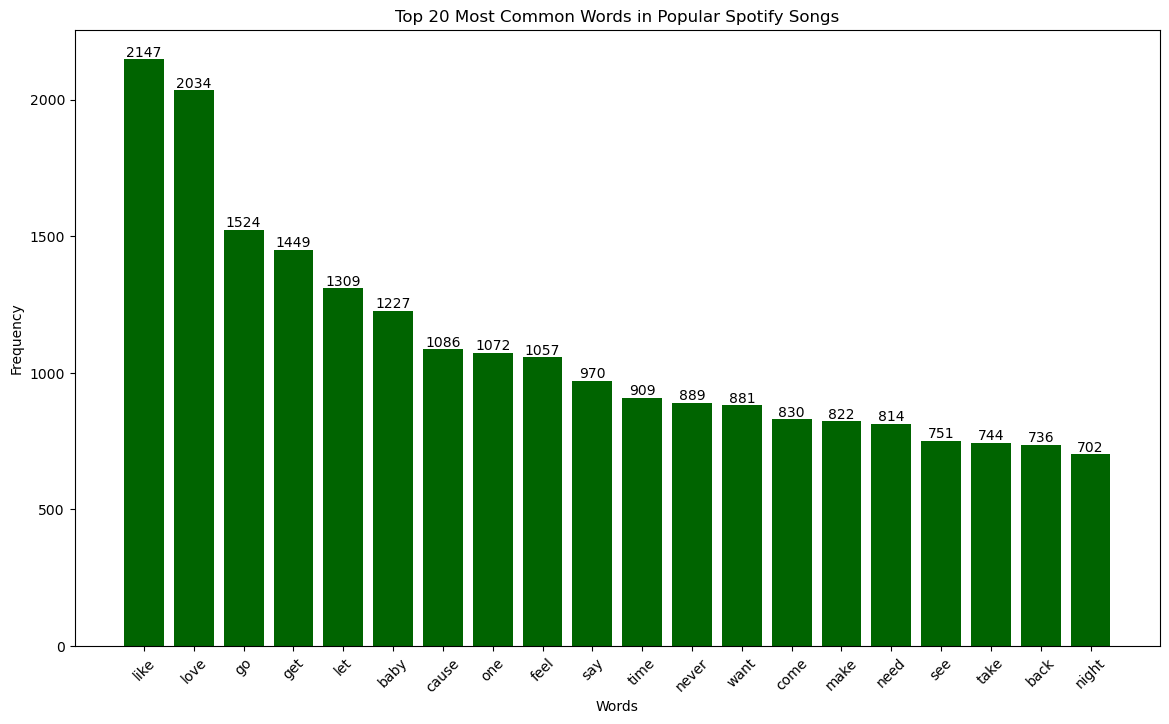

In [45]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

sp_data = pd.DataFrame(df_spotify_clean['lyrics'])

# Extract the lyrics column
lyrics = sp_data['lyrics'].dropna()

# Initialize the CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the lyrics data
X = vectorizer.fit_transform(lyrics)

# Sum the occurrences of each word
word_counts = X.sum(axis=0).A1

# Get the vocabulary (words) and their corresponding counts
vocab = vectorizer.get_feature_names_out()
word_freq = dict(zip(vocab, word_counts))

# Get the 20 most common words and their frequencies
common_words = pd.Series(word_freq).nlargest(20)

# Create the bar chart
plt.figure(figsize=(14, 8))
bars = plt.bar(common_words.index, common_words.values, color='darkgreen')
plt.title('Top 20 Most Common Words in Popular Spotify Songs')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(False)  # Disable the grid

# Add labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

# Save the bar chart to a file
plt.savefig("word_frequency_barchart.png", bbox_inches='tight', dpi=300)

# Show the bar chart
plt.show()

# TopicModeling

In [34]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from sklearn.metrics import jaccard_score


## TF-IDF

In [35]:
# TF-IDF Vectorization

tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Adjust max_features as needed
tfidf_matrix = tfidf_vectorizer.fit_transform(df_spotify_clean['lyrics'])

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

## LDA Model
1. Training LDA Model with sklearn

In [36]:
# Fit LDA Model and Print Top Words
num_topics_list = [5, 10, 15, 20]  # Example list of topic numbers
models = {}

for num_topics in num_topics_list:
    lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
    lda_output = lda_model.fit_transform(tfidf_matrix)
    models[num_topics] = lda_model

# Print top words for each model
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

feature_names = tfidf_vectorizer.get_feature_names_out()
for num_topics, model in models.items():
    print(f"Top words for {num_topics} topics:")
    print_top_words(model, feature_names, 5)
    print("\n")

Top words for 5 topics:
Topic 1: wishin, watch, dynamite, havent, rockstar
Topic 2: love, go, let, tonight, feel
Topic 3: africa, bass, marry, romance, trumpet
Topic 4: shy, sucker, enemy, bum, memoria
Topic 5: love, like, baby, get, go


Top words for 10 topics:
Topic 1: sunshine, hero, heartbreak, everybodys, baddest
Topic 2: true, wit, lithium, six, overdrive
Topic 3: together, singing, anywhere, mom, honest
Topic 4: shy, sucker, whistle, america, sexy
Topic 5: memoria, uptown, crack, hopeless, written
Topic 6: rise, africa, lean, anybody, rave
Topic 7: daylight, beggin, wouldve, bass, losin
Topic 8: love, like, go, baby, let
Topic 9: thunder, worried, knock, wasteland, golden
Topic 10: boom, enemy, dynamite, meet, dawn


Top words for 15 topics:
Topic 1: land, panda, age, uptown, funk
Topic 2: hello, wit, paradise, america, sunday
Topic 3: freak, shake, mmm, whoo, differ
Topic 4: laughing, rave, sucker, whatever, flag
Topic 5: boom, shy, lean, six, wild
Topic 6: breaking, rhythm, b

2. Evaluating Coherence with gensim

In [46]:
# Convert TF-IDF Matrix to gensim Corpus and Compute Coherence Scores
def tfidf_matrix_to_gensim_corpus(tfidf_matrix):
    from gensim.matutils import Sparse2Corpus
    return Sparse2Corpus(tfidf_matrix, documents_columns=False)

# Preprocess lyrics
def preprocess_lyrics(lyrics):
    return [lyric.split() for lyric in lyrics]

texts = preprocess_lyrics(df_spotify_clean['lyrics'])
dictionary = Dictionary(texts)
gensim_corpus = tfidf_matrix_to_gensim_corpus(tfidf_matrix)

coherence_scores = {}
for num_topics in num_topics_list:
    lda_model = LdaModel(
        corpus=gensim_corpus,
        id2word=dictionary,
        chunksize=500,
        alpha='auto',
        eta='auto',
        iterations=400,
        num_topics=num_topics,
        passes=20,
        random_state=42
    )
    coherencemodel = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_scores[num_topics] = coherencemodel.get_coherence()

print("Coherence Scores:")
for num_topics, score in coherence_scores.items():
    print(f"{num_topics} topics: Coherence Score = {score}")


Coherence Scores:
5 topics: Coherence Score = 0.7483223120832662
10 topics: Coherence Score = 0.7528264480992176
15 topics: Coherence Score = 0.7621435760076228
20 topics: Coherence Score = 0.7523281536442745


3. Visualizing the Model with pyLDAvis

15 Subjects

In [47]:
# Convert TF-IDF Matrix to gensim Corpus and Visualize the Model
def tfidf_matrix_to_gensim_corpus(tfidf_matrix):
    from gensim.matutils import Sparse2Corpus
    return Sparse2Corpus(tfidf_matrix, documents_columns=False)

gensim_corpus = tfidf_matrix_to_gensim_corpus(tfidf_matrix)
dictionary = Dictionary([tfidf_vectorizer.get_feature_names_out()])

lda_model = LdaModel(
    corpus=gensim_corpus,
    id2word=dictionary,
    chunksize=500,
    alpha='auto',
    eta='auto',
    iterations=400,
    num_topics=15,
    passes=20
)

# Visualize the LDA Model
vis_data = gensimvis.prepare(lda_model, gensim_corpus, dictionary)
pyLDAvis.display(vis_data)


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

4. Calculating Jaccard Similarity for Different Topic Numbers

In [48]:
# Compute Jaccard Similarity for Topic Models
def jaccard_similarity(topic_model_1, topic_model_2):
    topic_model_1_words = [set(topic_model_1.components_[i].argsort()[-11:-1]) for i in range(topic_model_1.n_components)]
    topic_model_2_words = [set(topic_model_2.components_[i].argsort()[-11:-1]) for i in range(topic_model_2.n_components)]

    similarity_matrix = np.zeros((len(topic_model_1_words), len(topic_model_2_words)))

    for i, words_1 in enumerate(topic_model_1_words):
        for j, words_2 in enumerate(topic_model_2_words):
            intersection = len(words_1.intersection(words_2))
            union = len(words_1.union(words_2))
            similarity_matrix[i, j] = intersection / union

    return similarity_matrix

jaccard_similarities = pd.DataFrame(index=num_topics_list, columns=num_topics_list)

for i, num_topics_i in enumerate(num_topics_list):
    for j, num_topics_j in enumerate(num_topics_list):
        if num_topics_i != num_topics_j:
            similarity = jaccard_similarity(models[num_topics_i], models[num_topics_j])
            avg_similarity = np.mean(similarity)
            jaccard_similarities.loc[num_topics_i, num_topics_j] = avg_similarity

print("Jaccard Similarity Matrix:")
print(jaccard_similarities)


Jaccard Similarity Matrix:
          5         10        15        20
5        NaN    0.0425  0.028787   0.02697
10    0.0425       NaN  0.023438  0.020103
15  0.028787  0.023438       NaN  0.017469
20   0.02697  0.020103  0.017469       NaN


5. Improving The Model

20 Subjects

In [ ]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel

# Convert TF-IDF matrix to gensim corpus
def tfidf_matrix_to_gensim_corpus(tfidf_matrix):
    from gensim.matutils import Sparse2Corpus
    return Sparse2Corpus(tfidf_matrix, documents_columns=False)

gensim_corpus = tfidf_matrix_to_gensim_corpus(tfidf_matrix)
dictionary = Dictionary([tfidf_vectorizer.get_feature_names_out()])

# Define and train the LDA model with 20 topics
lda_model_3 = LdaModel(
    corpus=gensim_corpus,
    id2word=dictionary,
    chunksize=500,
    alpha='auto',
    eta='auto',
    iterations=400,
    num_topics=20,
    passes=20,
    random_state=42
)


# Visualize the LDA Model with 20 topics
vis_data_3 = gensimvis.prepare(lda_model_3, gensim_corpus, dictionary)
pyLDAvis.display(vis_data_3)

10 Subjects

In [ ]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel

# Convert TF-IDF matrix to gensim corpus
def tfidf_matrix_to_gensim_corpus(tfidf_matrix):
    from gensim.matutils import Sparse2Corpus
    return Sparse2Corpus(tfidf_matrix, documents_columns=False)

gensim_corpus = tfidf_matrix_to_gensim_corpus(tfidf_matrix)
dictionary = Dictionary([tfidf_vectorizer.get_feature_names_out()])

# Define and train the LDA model with 10 topics
lda_model_3 = LdaModel(
    corpus=gensim_corpus,
    id2word=dictionary,
    chunksize=500,
    alpha='auto',
    eta='auto',
    iterations=400,
    num_topics=10,
    passes=20,
    random_state=42
)


# Visualize the LDA Model with 10 topics
vis_data_3 = gensimvis.prepare(lda_model_3, gensim_corpus, dictionary)
pyLDAvis.display(vis_data_3)

5 Subjects

In [ ]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel

# Convert TF-IDF matrix to gensim corpus
def tfidf_matrix_to_gensim_corpus(tfidf_matrix):
    from gensim.matutils import Sparse2Corpus
    return Sparse2Corpus(tfidf_matrix, documents_columns=False)

gensim_corpus = tfidf_matrix_to_gensim_corpus(tfidf_matrix)
dictionary = Dictionary([tfidf_vectorizer.get_feature_names_out()])

# Define and train the LDA model with 5 topics
lda_model_3 = LdaModel(
    corpus=gensim_corpus,
    id2word=dictionary,
    chunksize=500,
    alpha='auto',
    eta='auto',
    iterations=400,
    num_topics=5,
    passes=20,
    random_state=42
)


# Visualize the LDA Model with 5 topics
vis_data_3 = gensimvis.prepare(lda_model_3, gensim_corpus, dictionary)
pyLDAvis.display(vis_data_3)

3 Subjects

In [ ]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel

# Convert TF-IDF matrix to gensim corpus
def tfidf_matrix_to_gensim_corpus(tfidf_matrix):
    from gensim.matutils import Sparse2Corpus
    return Sparse2Corpus(tfidf_matrix, documents_columns=False)

gensim_corpus = tfidf_matrix_to_gensim_corpus(tfidf_matrix)
dictionary = Dictionary([tfidf_vectorizer.get_feature_names_out()])

# Define and train the LDA model with 3 topics
lda_model_3 = LdaModel(
    corpus=gensim_corpus,
    id2word=dictionary,
    chunksize=500,
    alpha='auto',
    eta='auto',
    iterations=400,
    num_topics=3,
    passes=20,
    random_state=42
)


# Visualize the LDA Model with 3 topics
vis_data_3 = gensimvis.prepare(lda_model_3, gensim_corpus, dictionary)
pyLDAvis.display(vis_data_3)

2 Subjects

In [ ]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel

# Convert TF-IDF matrix to gensim corpus
def tfidf_matrix_to_gensim_corpus(tfidf_matrix):
    from gensim.matutils import Sparse2Corpus
    return Sparse2Corpus(tfidf_matrix, documents_columns=False)

gensim_corpus = tfidf_matrix_to_gensim_corpus(tfidf_matrix)
dictionary = Dictionary([tfidf_vectorizer.get_feature_names_out()])

# Define and train the LDA model with 2 topics
lda_model_3 = LdaModel(
    corpus=gensim_corpus,
    id2word=dictionary,
    chunksize=500,
    alpha='auto',
    eta='auto',
    iterations=400,
    num_topics=2,
    passes=20,
    random_state=42
)

# Visualize the LDA Model with 2 topics
vis_data_3 = gensimvis.prepare(lda_model_3, gensim_corpus, dictionary)
pyLDAvis.display(vis_data_3)

6. The Chosen Num of Subjects

In [ ]:
# Define and train the LDA model with 2 topics
lda_model_2 = LdaModel(
    corpus=gensim_corpus,
    id2word=dictionary,
    chunksize=500,
    alpha='auto',
    eta='auto',
    iterations=400,
    num_topics=2,
    passes=20,
    random_state=42
)

# Visualize the LDA Model with 2 topics
vis_data_2 = gensimvis.prepare(lda_model_2, gensim_corpus, dictionary)
pyLDAvis.display(vis_data_2)

# Print top words for each topic
def print_top_words(model, n_top_words):
    for topic_idx in range(model.num_topics):
        top_words = [word for word, _ in model.show_topic(topic_idx, topn=n_top_words)]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

print("Top words for 2 topics:")
print_top_words(lda_model_2, 5)
print("\n")

# Calculate and print coherence score for the model with 2 topics
coherencemodel = CoherenceModel(model=lda_model_2, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_score = coherencemodel.get_coherence()

print(f"Coherence Score for 2 topics: {coherence_score}")


## WordCloud

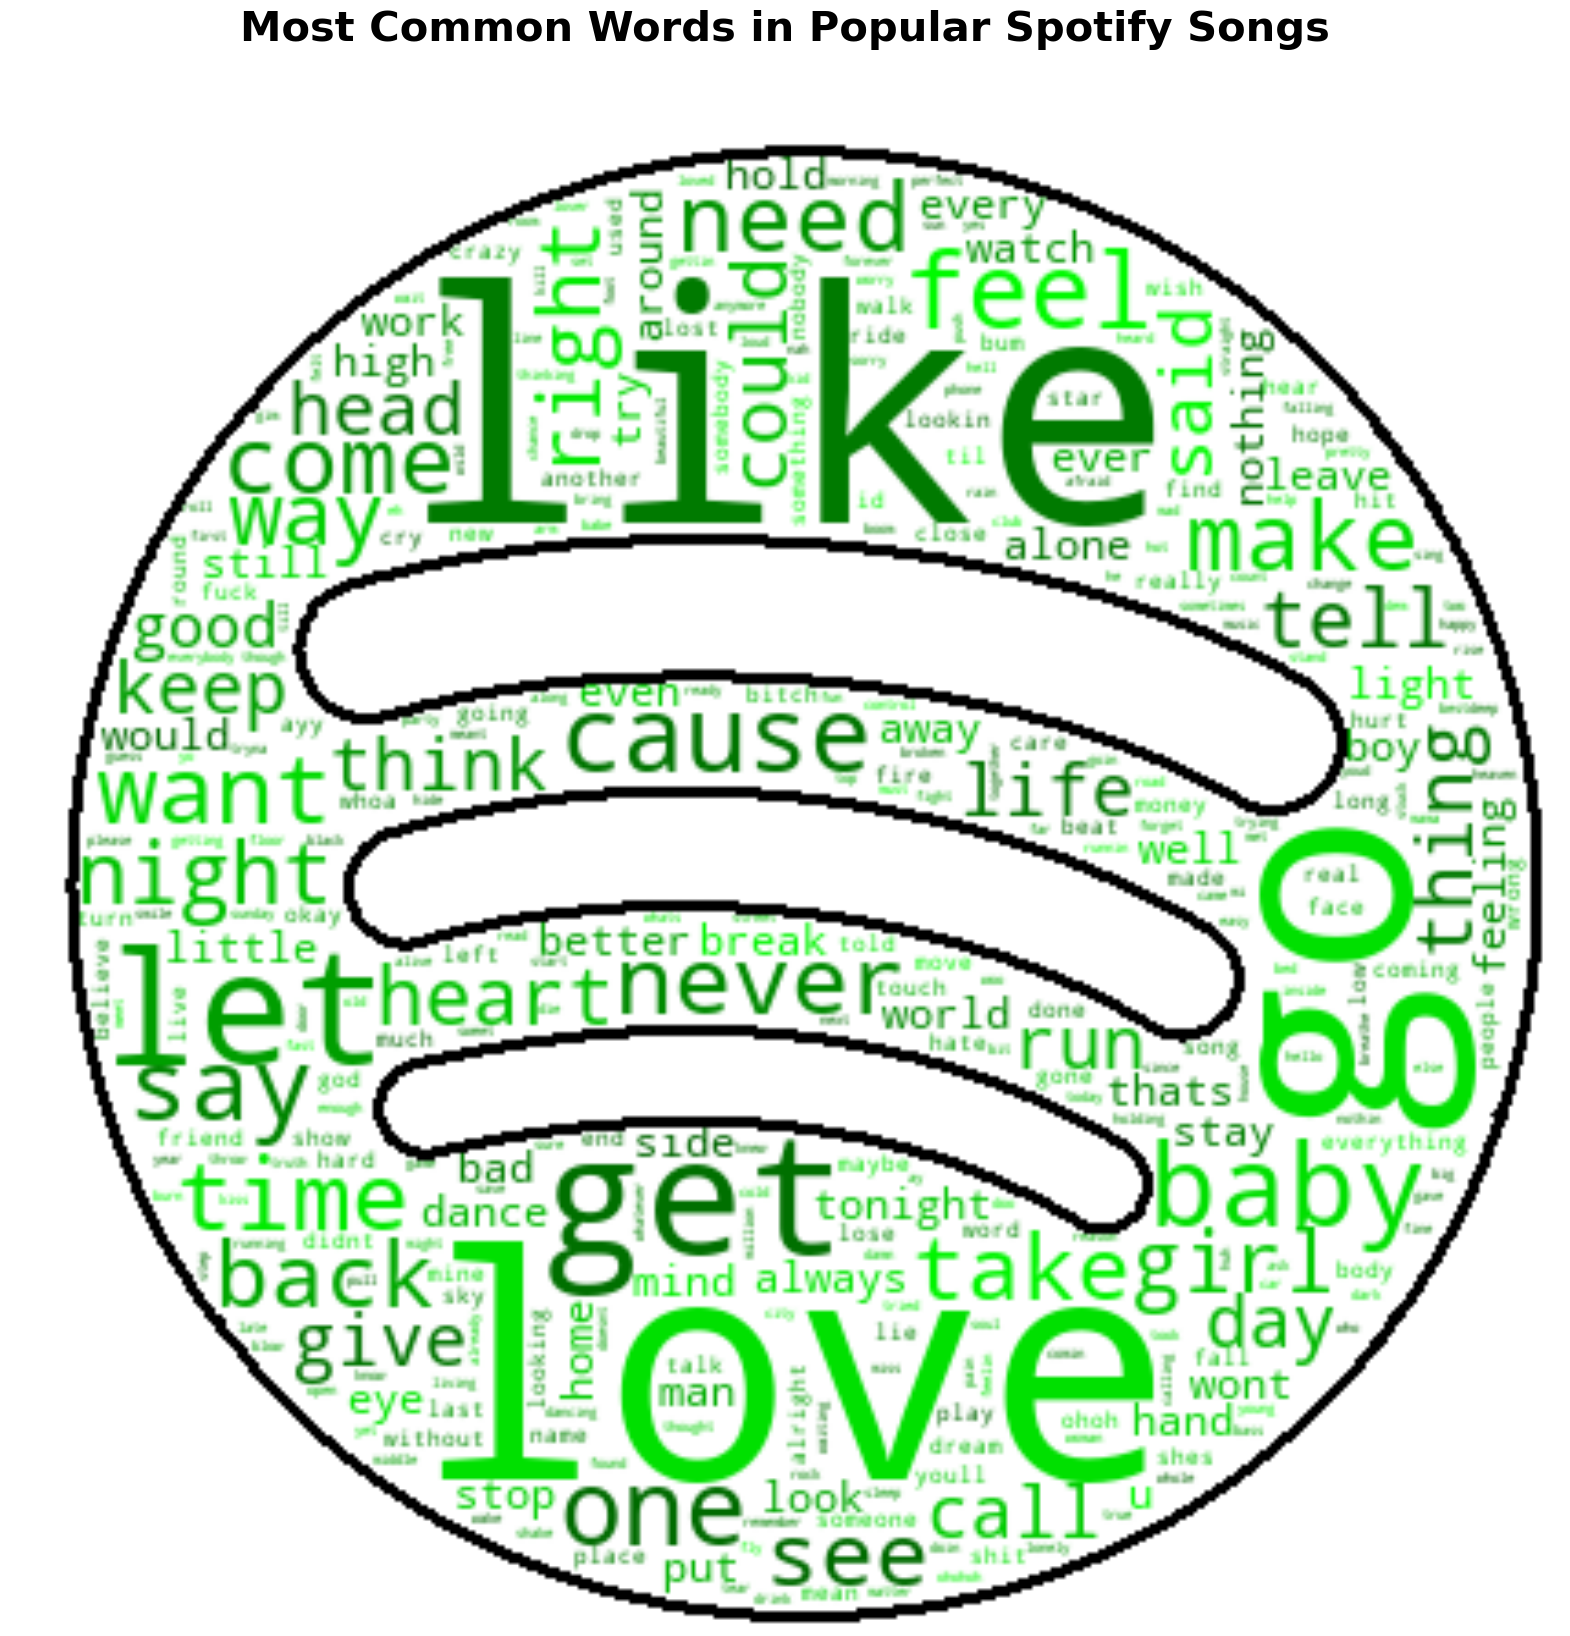

In [41]:
# Libraries
from wordcloud import WordCloud
import numpy as np
from PIL import Image
import os

# Load the Spotify logo image
spotify_image = np.array(Image.open("SpotifyImage4.png"))

# Create mask that retains words only in the green area of the image
mask_image_transformed = np.ndarray((spotify_image.shape[0], spotify_image.shape[1]), np.int32)

for i in range(len(spotify_image)):
    for j in range(len(spotify_image[0])):
        if spotify_image[i][j][1] > 150 and spotify_image[i][j][0] < 100 and spotify_image[i][j][2] < 100:  # Green color check
            mask_image_transformed[i][j] = 0
        else:
            mask_image_transformed[i][j] = 255

# Function to generate dark green colors
def dark_green_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(120, 100%, {}%)".format(np.random.randint(20, 50))

# Creating the word cloud
wordcloud = WordCloud(background_color="white", max_words=1000, mask=mask_image_transformed,
                      color_func=dark_green_color_func, contour_width=2,
                      contour_color='black')

# Creating the word cloud from the frequencies
wordcloud.generate_from_frequencies(words)

# Displaying the word cloud with title
plt.figure(figsize=[20, 20])
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

# Adding the title above the graph
plt.text(0.5, 1.05, 'Most Common Words in Popular Spotify Songs', horizontalalignment='center',
         verticalalignment='center', transform=plt.gca().transAxes, fontsize=30, fontweight='bold')

# Saving the word cloud to a file
plt.savefig("wordcloud_dark_green.png", bbox_inches='tight', dpi=300)

# Show the word cloud
plt.show()